# **T2B** Lei de Stefan Boltzmann

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import RealData, Model, ODR
import sys
sys.path.append("../..")
import base as b
import importlib
importlib.reload(b)

<module 'base' from 'c:\\Users\\User\\Desktop\\uni\\2ano\\labs\\labs II\\semana2\\T2B - Radiação Térmica\\../..\\base\\__init__.py'>

## Temperatura ambiente

In [10]:
U,uU,I,uI=b.getData('Ambvall.txt')
#adjust = b.plotLinReg(I,U,uU,uI,"R ambiente", "I(mA)", "U (mV)",)
print(U,uU,I,uI)

[1.3 2.  2.6 3.  3.5 4.6 5.1 5.8 6.6 7.3 7.9 8.6 9.1 9.7] [0.11 0.11 0.11 0.11 0.11 0.12 0.12 0.12 0.13 0.13 0.13 0.13 0.14 0.14] [ 2.63  4.    5.13  5.9   6.9   9.07 10.05 11.5  13.01 14.31 15.5  17.
 18.06 19.15] [0.031 0.042 0.051 0.057 0.065 0.083 0.09  0.1   0.11  0.12  0.13  0.15
 0.15  0.16 ]


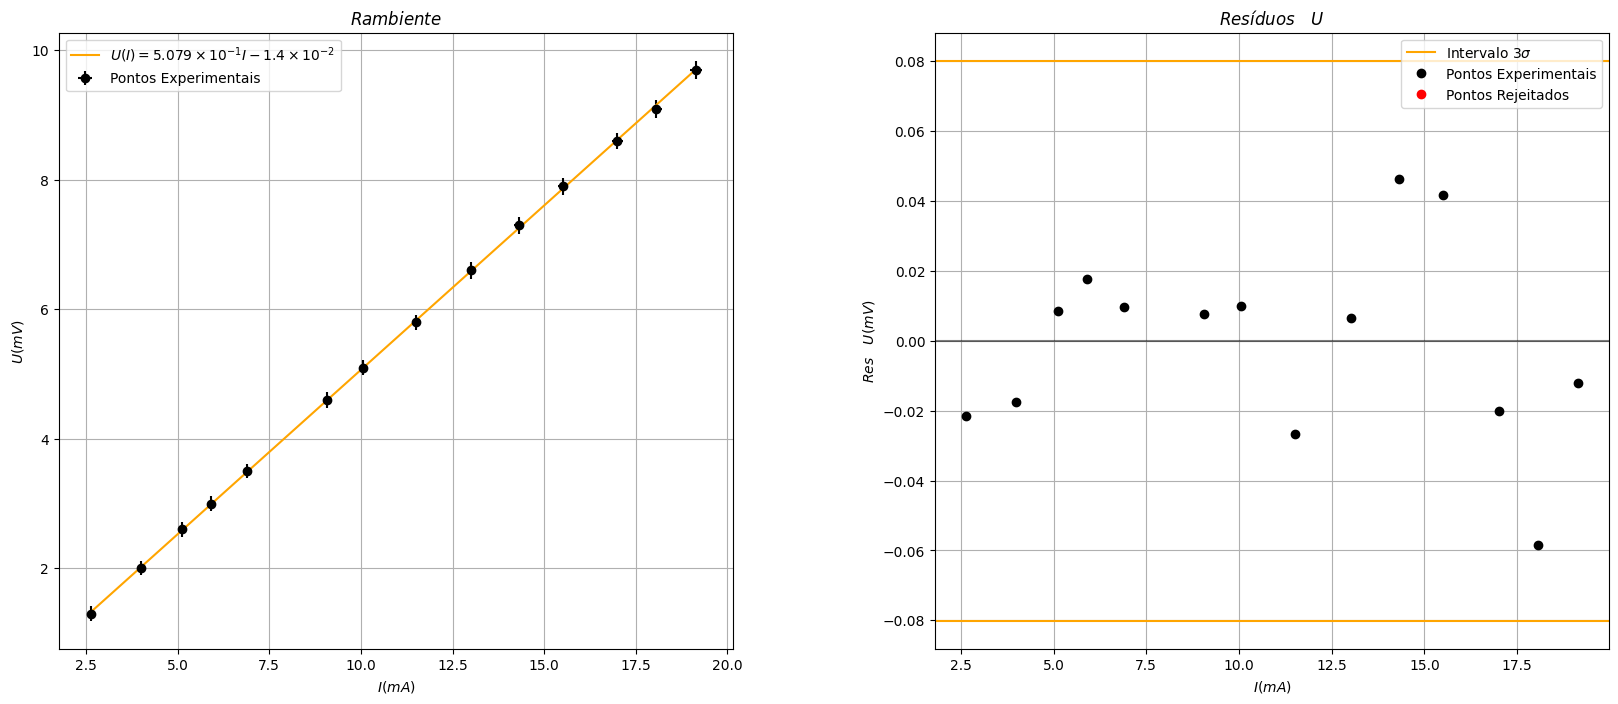

In [6]:

titles = ['R ambiente']
xlabels = ['I(mA)']
ylabels = ['U (mV)']
adjustR = b.plotColumnFullLinReg([I],[U],[uI],[uU],titles,xlabels,ylabels,tol=3)

In [11]:
Ramb=adjustR[0].beta[0]
uRamb=adjustR[0].sd_beta[0]

print("Resistência da lâmpada a temperatura ambiente")
print()
print(f"R = {Ramb:.4f} ± {uRamb:.4f} Ω")

Resistência da lâmpada a temperatura ambiente

R = 0.5079 ± 0.0014 Ω


## Aquecimento

In [12]:
I, uI,U, uU = b.getData("T2B_UI_aquecimento.txt")

#adjust = b.plotQuadReg(I,U,uI,uU,"U(I)","I (A)","U (V)")

#print("A tensão varia quadraticamente com a corrente")
#print(f"U(I) = {adjust.beta[0]:.2f}I² + {adjust.beta[1]:.2f}I {adjust.beta[2]:.2f}")

O facto da Tensão variar quadraticamente com a Corrente significa que a Resistência do filamento varia com a Temperatura, visto que há medida que a tensão aumenta, o filamento aumenta  a temperatura

In [13]:
R,uR,P,uP,T=b.getData('T2B_Res_Pot_Temp.txt')
T4=T**4

In [14]:
def uT(R, Ramb, uR, uRamb):
    return abs(-3.2362*(R/Ramb) + 202.98) * np.sqrt((uR/Ramb)**2 + (R*uRamb/Ramb**2)**2)

In [15]:
uT4=4*T**3*uT(R,Ramb,uR,uRamb)

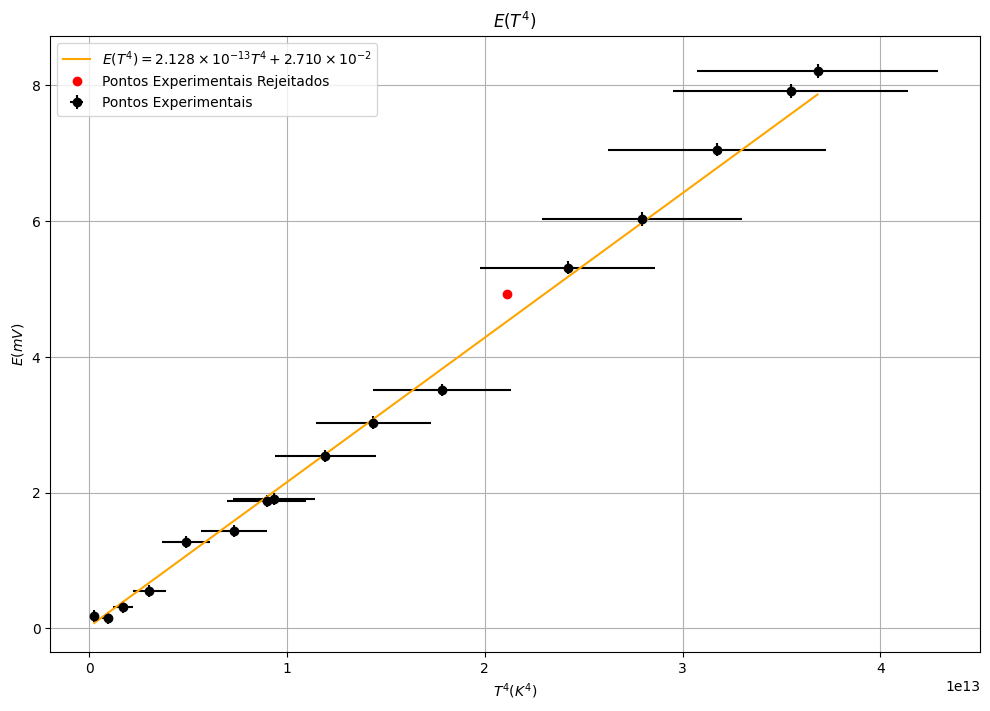

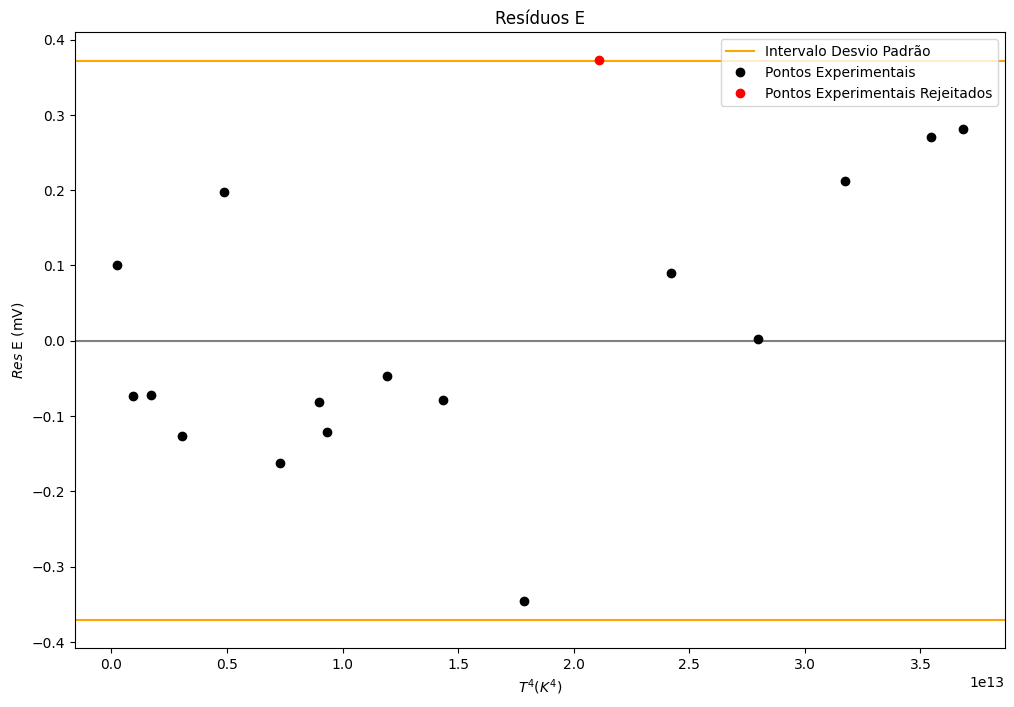

Beta: [2.12757985e-13 2.70953638e-02]
Beta Std Error: [6.63386275e-15 3.09479840e-02]
Beta Covariance: [[ 1.71579276e-28 -3.56355041e-16]
 [-3.56355041e-16  3.73419156e-03]]
Residual Variance: 0.256488638757351
Inverse Condition #: 1.9194069094621465e-13
Reason(s) for Halting:
  Sum of squares convergence


In [20]:
#Edark, Eillum = b.getData('T2B_Edarkillum.txt')
#E = Eillum - Edark
E,uE=b.getData('Eval.txt')

adjustFinal = b.fullLinAnalysis(T4,E,uT4,uE, "E (T^4)", "T^4 (K^4)", "E (mV)", tol=2)
adjustFinal.pprint()

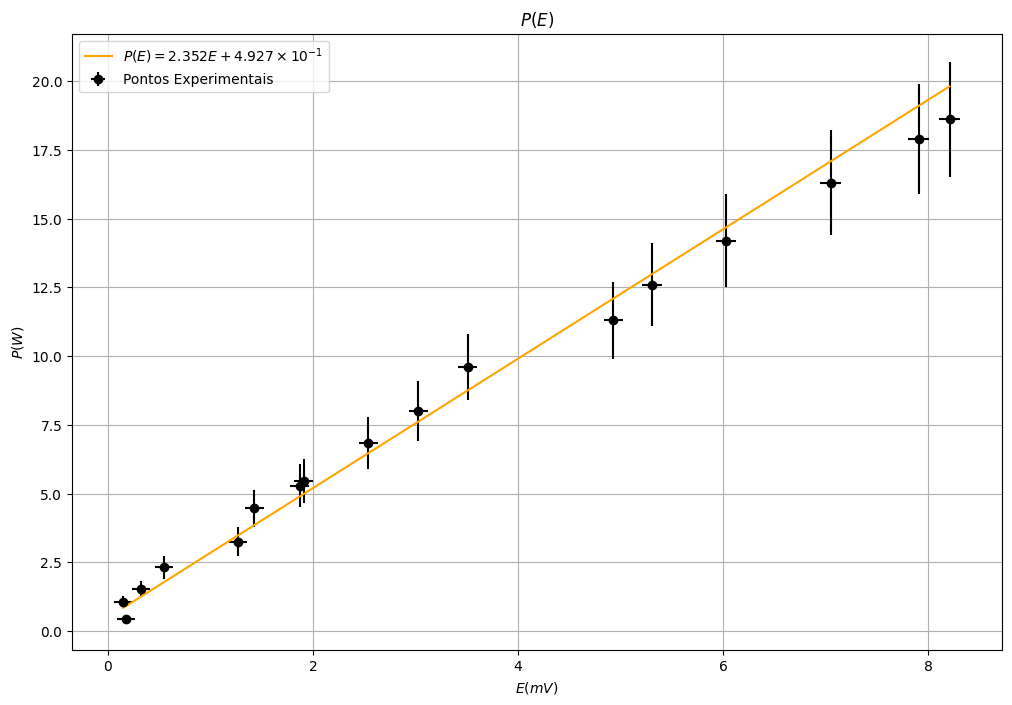

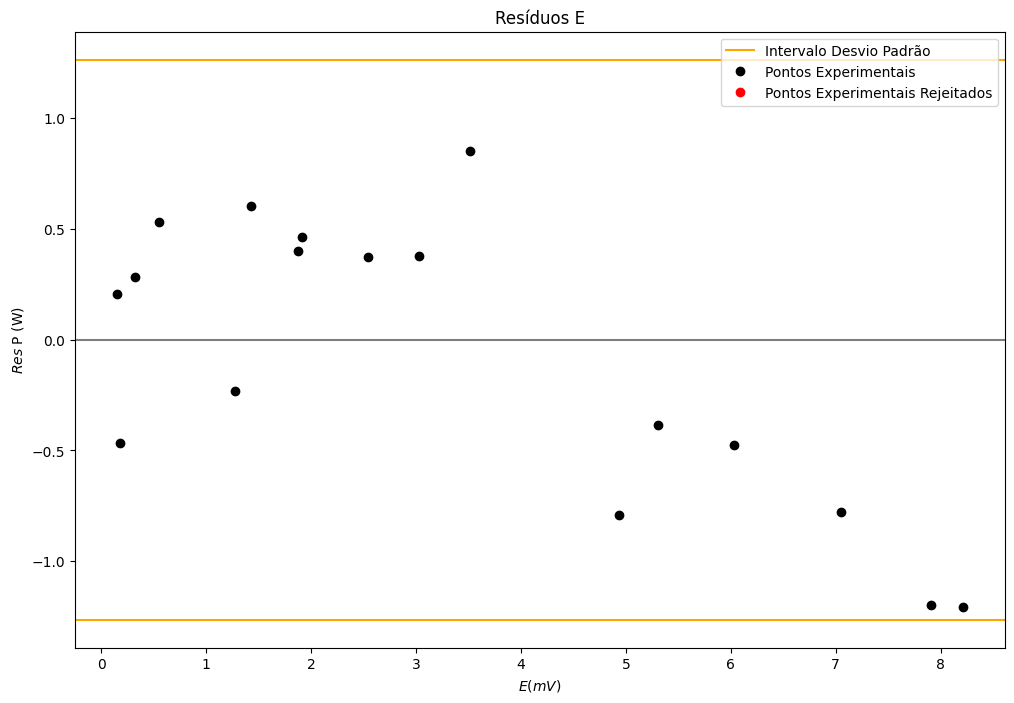

Beta: [2.35224114 0.49265454]
Beta Std Error: [0.08319768 0.12623888]
Beta Covariance: [[ 0.0104025  -0.00773915]
 [-0.00773915  0.02394977]]
Residual Variance: 0.6654031414264152
Inverse Condition #: 0.5238458637903743
Reason(s) for Halting:
  Sum of squares convergence


In [19]:
d = .06
A = 3e-5
sb= 5.67e-8



adjust = b.fullLinAnalysis(E,P,uE,uP,"P(E)","E (mV)","P (W)",tol=2)
adjust.pprint()


Beta: [2.05138799e-13 3.03818068e-02]
Beta Std Error: [8.92123960e-15 3.26926009e-02]
Beta Covariance: [[ 2.94028486e-28 -5.05309167e-16]
 [-5.05309167e-16  3.94855276e-03]]
Residual Variance: 0.2706830118066208
Inverse Condition #: 2.4101394002421187e-13
Reason(s) for Halting:
  Sum of squares convergence
Beta: [2.47370386 0.4368291 ]
Beta Std Error: [0.13255672 0.14616516]
Beta Covariance: [[ 0.02295624 -0.01369917]
 [-0.01369917  0.02791162]]
Residual Variance: 0.7654252092510778
Inverse Condition #: 0.4889438077962825
Reason(s) for Halting:
  Sum of squares convergence


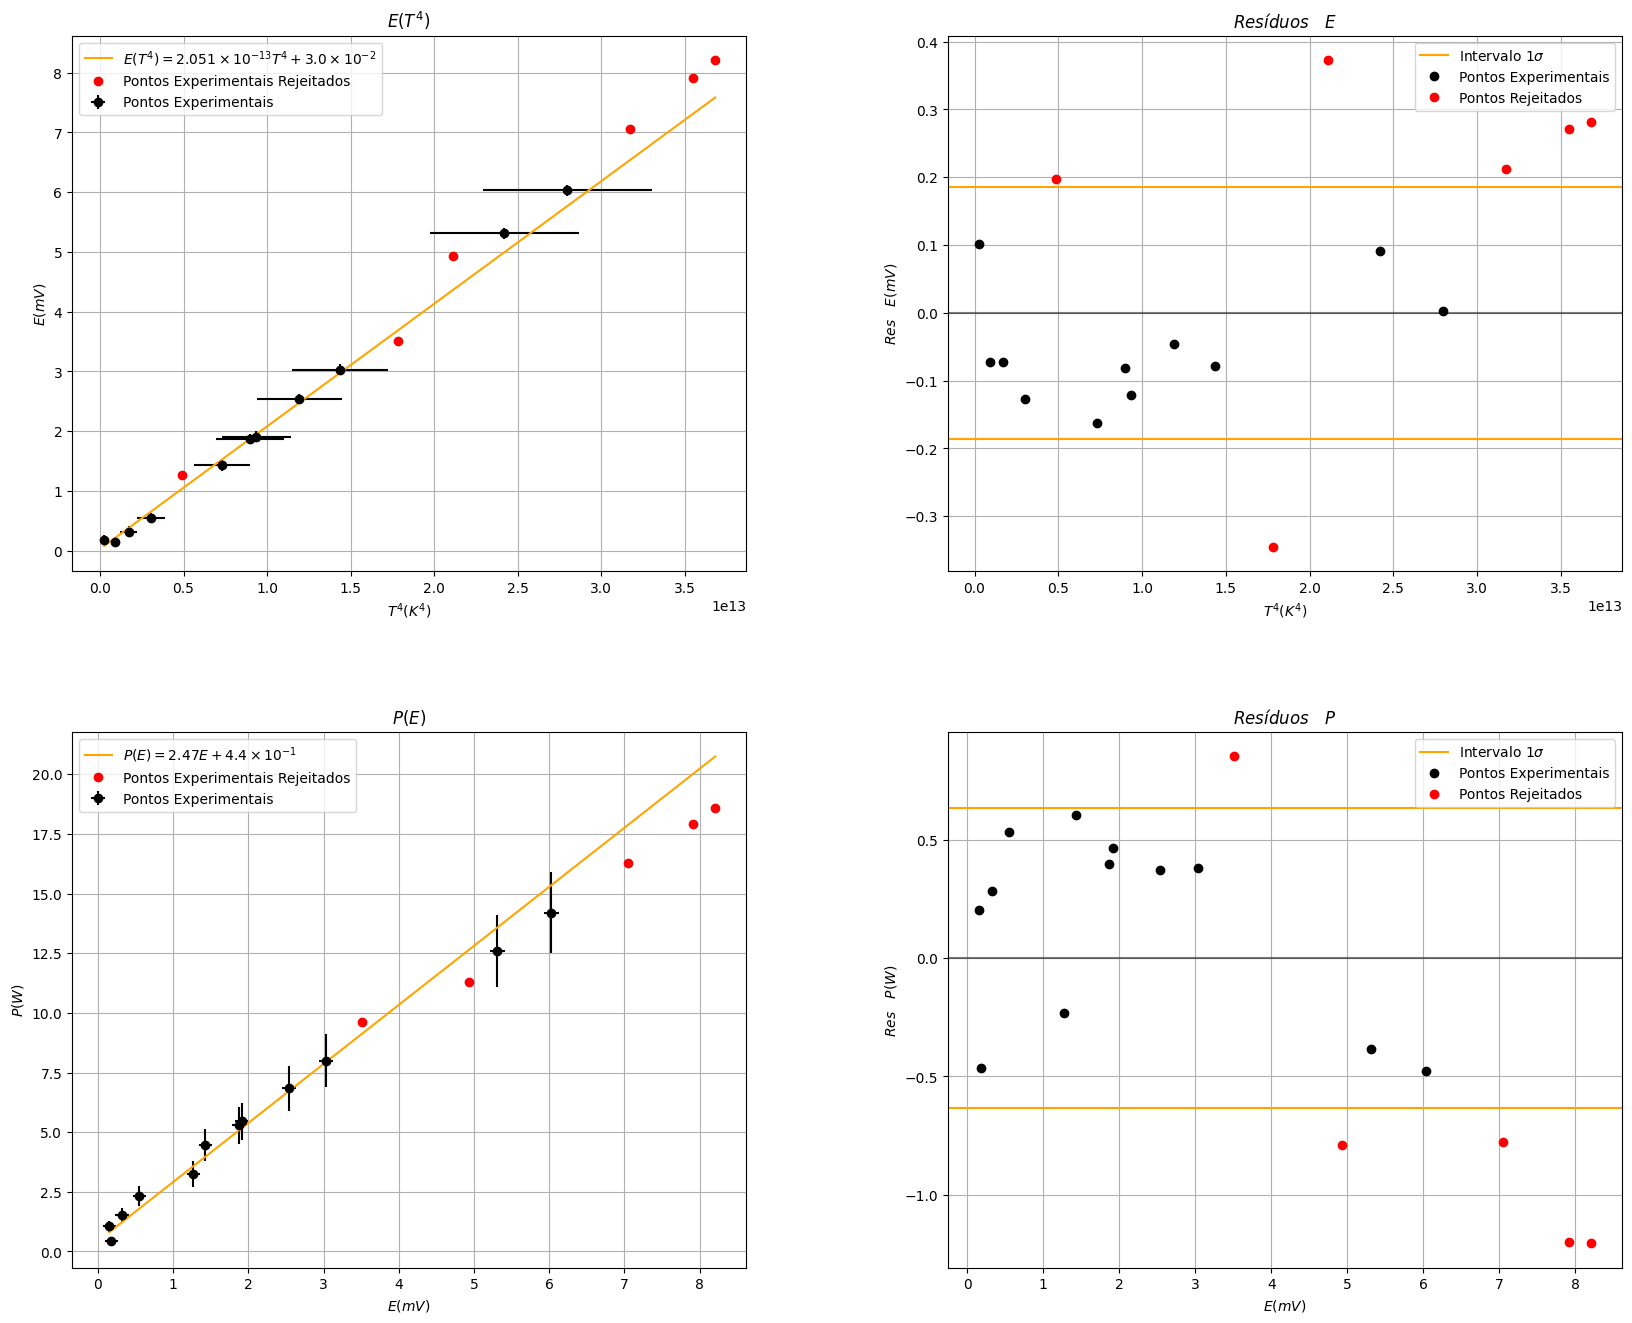

In [ ]:
xs = [T4,E]
ys = [E,P]
xerrs = [uT4,uE]
yerrs = [uE,uP]
titles = ['E(T^4)','P(E)']
xlabels = ['T^4(K^4)','E(mV)']
ylabels = ['E(mV)','P(W)']
adjustFinal = b.plotColumnFullLinReg(xs,ys,xerrs,yerrs,titles,xlabels,ylabels,tol=1)
adjustFinal[0].pprint()
adjustFinal[1].pprint()
